# 1. Perkenalan Dataset

**Nama:** Luhung Pandyaska Suyi  
**Dataset:** Heart Disease Data - UCI Machine Learning Repository  
**URL Sumber:** [Kaggle Heart Disease Data](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)


**Deskripsi Dataset:**

Dataset Heart Disease UCI merupakan kumpulan data klinis pasien yang dikumpulkan dari beberapa institusi medis (Cleveland, Hungary, Switzerland, Long Beach VA). Dataset ini berisi **303 instance** (versi Cleveland) hingga **920 instance** (gabungan) dengan **14 fitur utama** dan 1 label kelas.

**Fitur-fitur dataset:**
| Fitur | Deskripsi | Tipe |
|-------|-----------|------|
| `age` | Usia pasien (tahun) | Numerik |
| `sex` | Jenis kelamin (1=Pria, 0=Wanita) | Kategorikal |
| `cp` | Tipe nyeri dada (0-3) | Kategorikal |
| `trestbps` | Tekanan darah saat istirahat (mm Hg) | Numerik |
| `chol` | Kolesterol serum (mg/dl) | Numerik |
| `fbs` | Gula darah puasa > 120 mg/dl (1=Ya, 0=Tidak) | Kategorikal |
| `restecg` | Hasil EKG saat istirahat (0-2) | Kategorikal |
| `thalach` | Detak jantung maksimum yang dicapai | Numerik |
| `exang` | Angina akibat olahraga (1=Ya, 0=Tidak) | Kategorikal |
| `oldpeak` | Depresi ST akibat olahraga relatif terhadap istirahat | Numerik |
| `slope` | Kemiringan segmen ST puncak saat olahraga (0-2) | Kategorikal |
| `ca` | Jumlah pembuluh darah utama (0-3) yang terlihat fluoroskopi | Numerik |
| `thal` | Status thalassemia (1=Normal, 2=Fixed Defect, 3=Reversible Defect) | Kategorikal |

**Target:** Kolom `num` — nilai 0 menunjukkan tidak ada penyakit jantung, nilai 1–4 menunjukkan tingkat keparahan penyakit jantung.  
Untuk keperluan klasifikasi **biner**, nilai > 0 dikonversi menjadi 1 (ada penyakit).

**Tantangan utama:**
- Terdapat missing values pada beberapa fitur (`ca`, `thal`, `slope`).
- Potensi class imbalance antara pasien sehat dan sakit.
- Campuran fitur numerik dan kategorikal memerlukan preprocessing berbeda.


# 2. Import Library

In [25]:
# Install semua dependensi yang dibutuhkan
!pip install numpy>=1.24 pandas>=2.0 matplotlib>=3.7 seaborn>=0.12 \
    scikit-learn>=1.3 imbalanced-learn>=0.11 mlflow>=2.10 joblib>=1.3

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import mlflow
import mlflow.sklearn
import joblib
import shutil

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


# 3. Memuat Dataset

In [3]:
DATA_PATH = 'heart_disease_uci.csv'

# Coba muat dari file lokal; jika tidak ada, gunakan URL alternatif
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'✅ Dataset dimuat dari file lokal: {DATA_PATH}')
else:
    # Fallback: Cleveland Heart Disease dari UCI via raw GitHub
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    col_names = ['age','sex','cp','trestbps','chol','fbs','restecg',
                 'thalach','exang','oldpeak','slope','ca','thal','num']
    df = pd.read_csv(url, header=None, names=col_names, na_values='?')
    print(f'Dataset dimuat dari UCI (Cleveland): {url}')

print(f'\nShape dataset: {df.shape}')
print(f'Kolom tersedia: {df.columns.tolist()}')

Dataset dimuat dari UCI (Cleveland): https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

Shape dataset: (303, 14)
Kolom tersedia: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [4]:
# Tampilkan 5 baris pertama
print('=== 5 Baris Pertama Dataset ===')
display(df.head())

print('\n=== Info Dataset ===')
df.info()

=== 5 Baris Pertama Dataset ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
display(df.describe(include='all'))

# Distribusi target awal
print('\n=== Distribusi Target (num) ===')
print(df['num'].value_counts().sort_index())

=== Statistik Deskriptif ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



=== Distribusi Target (num) ===
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [6]:
df['target'] = (df['num'] > 0).astype(int)

print('=== Distribusi Target Biner ===')
target_counts = df['target'].value_counts().sort_index()
target_labels = {0: 'Sehat (0)', 1: 'Penyakit Jantung (1)'}
for k, v in target_counts.items():
    print(f'  {target_labels[k]}: {v} ({v/len(df)*100:.1f}%)')

=== Distribusi Target Biner ===
  Sehat (0): 164 (54.1%)
  Penyakit Jantung (1): 139 (45.9%)


# 4. Exploratory Data Analysis (EDA)

## 4.1 Distribusi Target

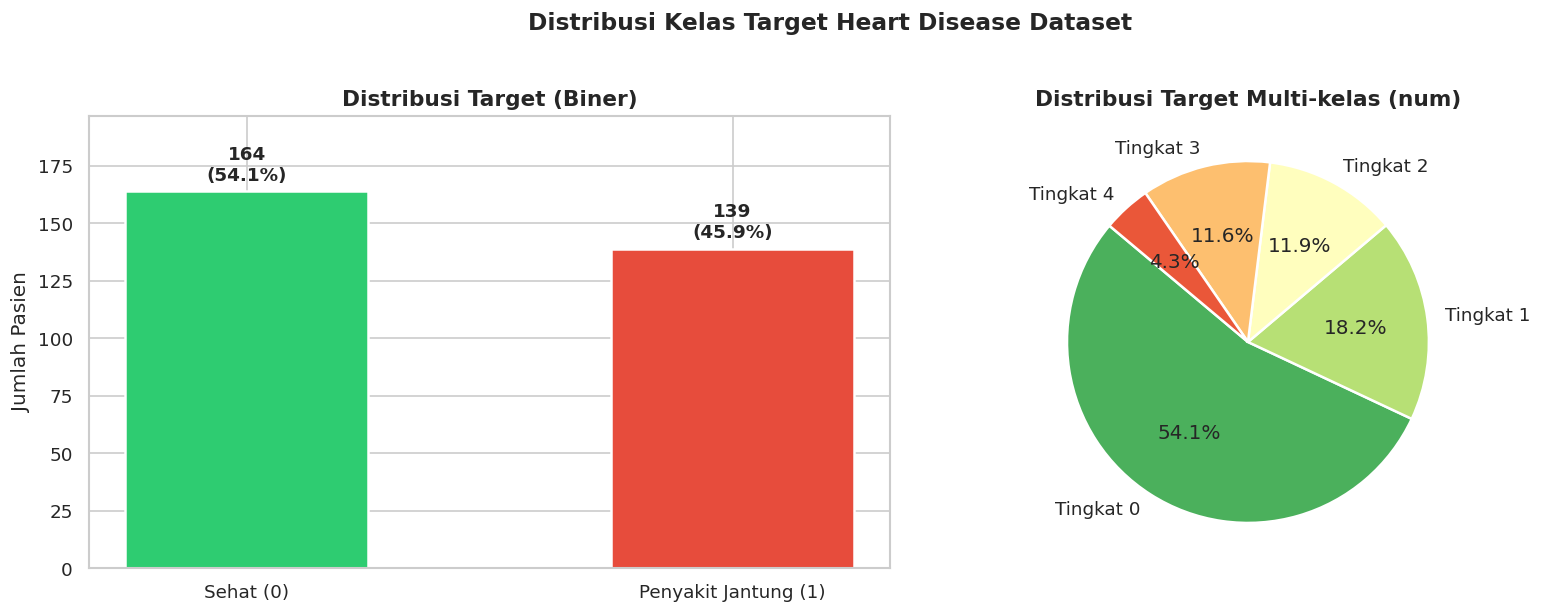

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Distribusi target biner (bar chart) ---
colors = ['#2ecc71', '#e74c3c']
labels = ['Sehat (0)', 'Penyakit Jantung (1)']
counts = df['target'].value_counts().sort_index()
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Distribusi Target (Biner)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].set_ylim(0, counts.max() * 1.2)

# --- Plot 2: Distribusi target multi-kelas (pie chart) ---
num_counts = df['num'].value_counts().sort_index()
num_labels = [f'Tingkat {i}' for i in num_counts.index]
palette = sns.color_palette('RdYlGn_r', len(num_counts))
axes[1].pie(num_counts.values, labels=num_labels, autopct='%1.1f%%',
            colors=palette, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribusi Target Multi-kelas (num)', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Kelas Target Heart Disease Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.2 Distribusi Fitur Numerik

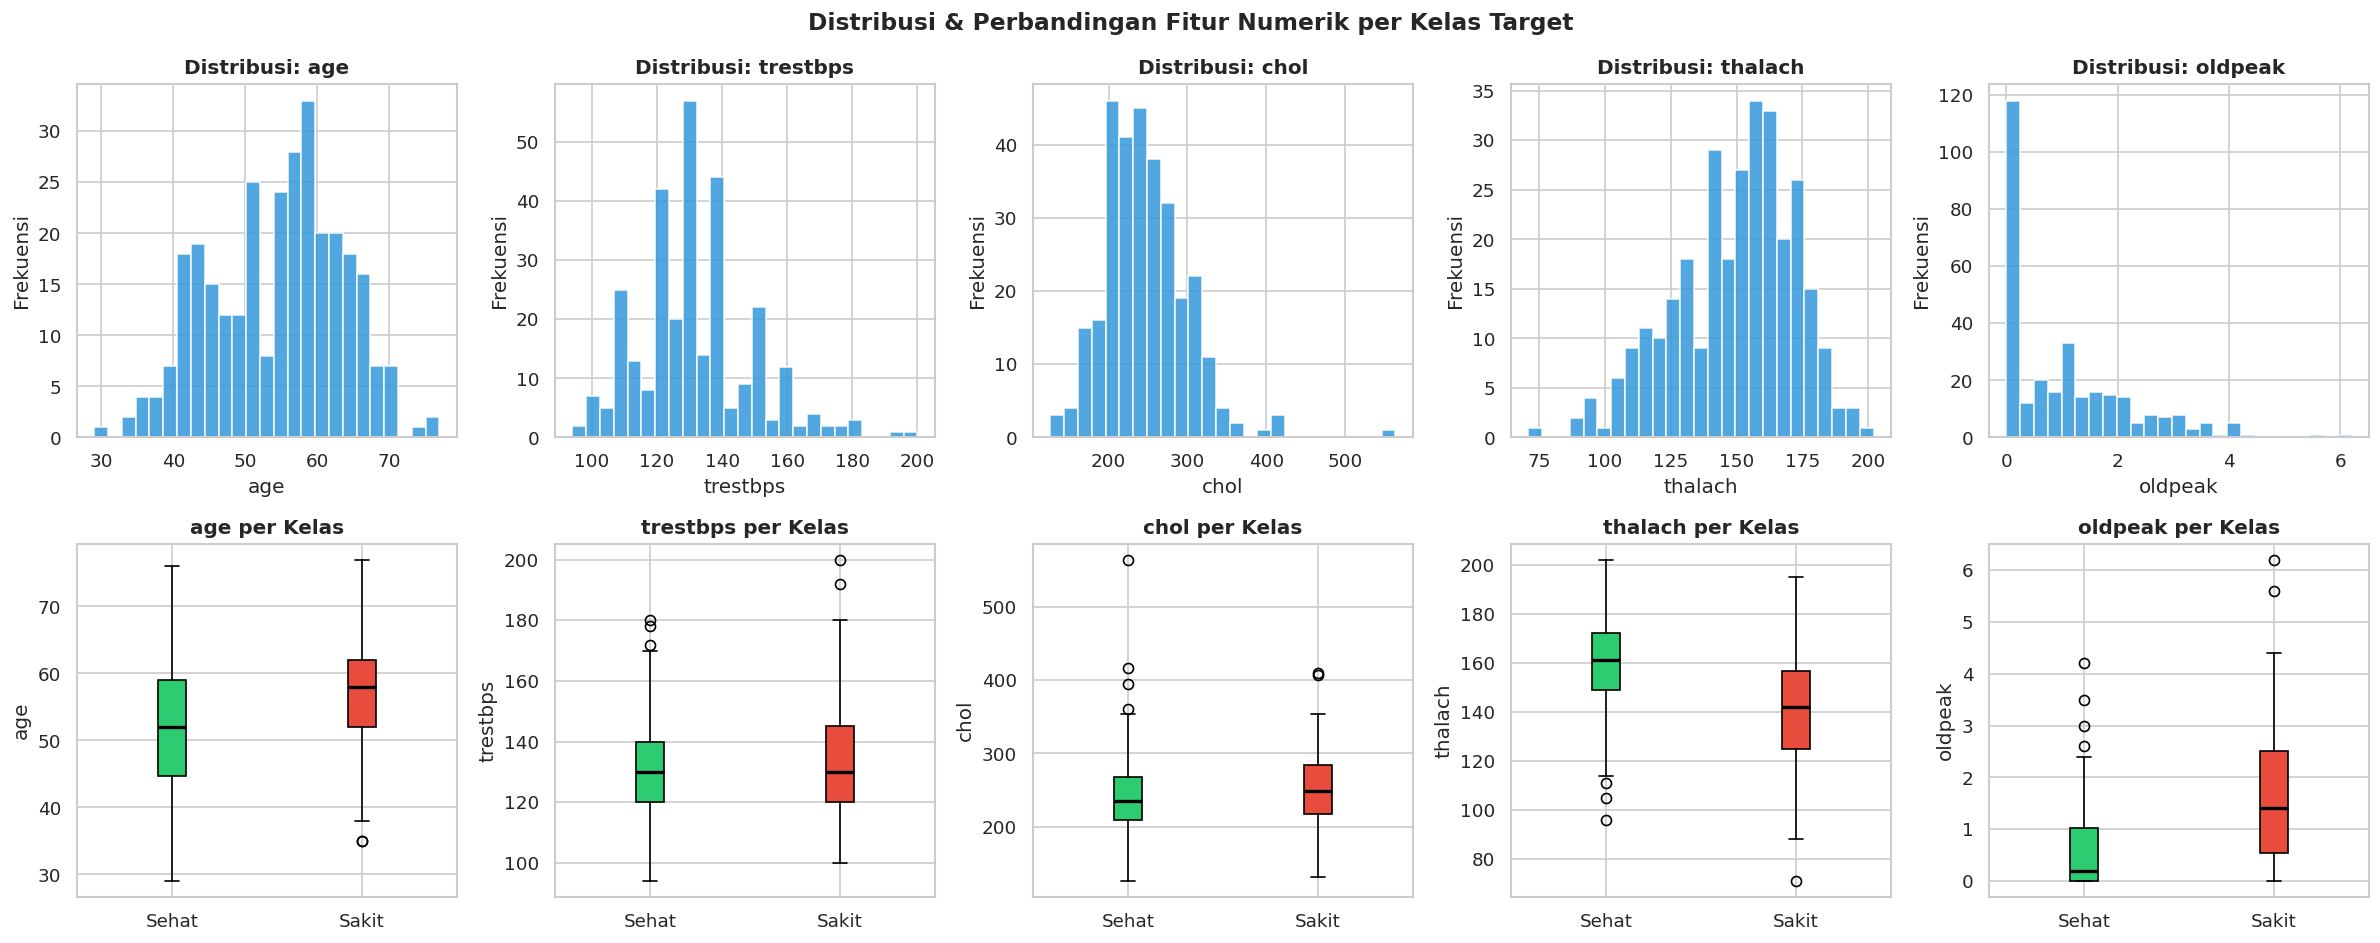

In [8]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=25, color='#3498db', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot per kelas target
    data_0 = df.loc[df['target'] == 0, col].dropna()
    data_1 = df.loc[df['target'] == 1, col].dropna()
    bp = axes[1, i].boxplot([data_0, data_1],
                             labels=['Sehat', 'Sakit'],
                             patch_artist=True,
                             medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[1, i].set_title(f'{col} per Kelas', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribusi & Perbandingan Fitur Numerik per Kelas Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Distribusi Fitur Kategorikal

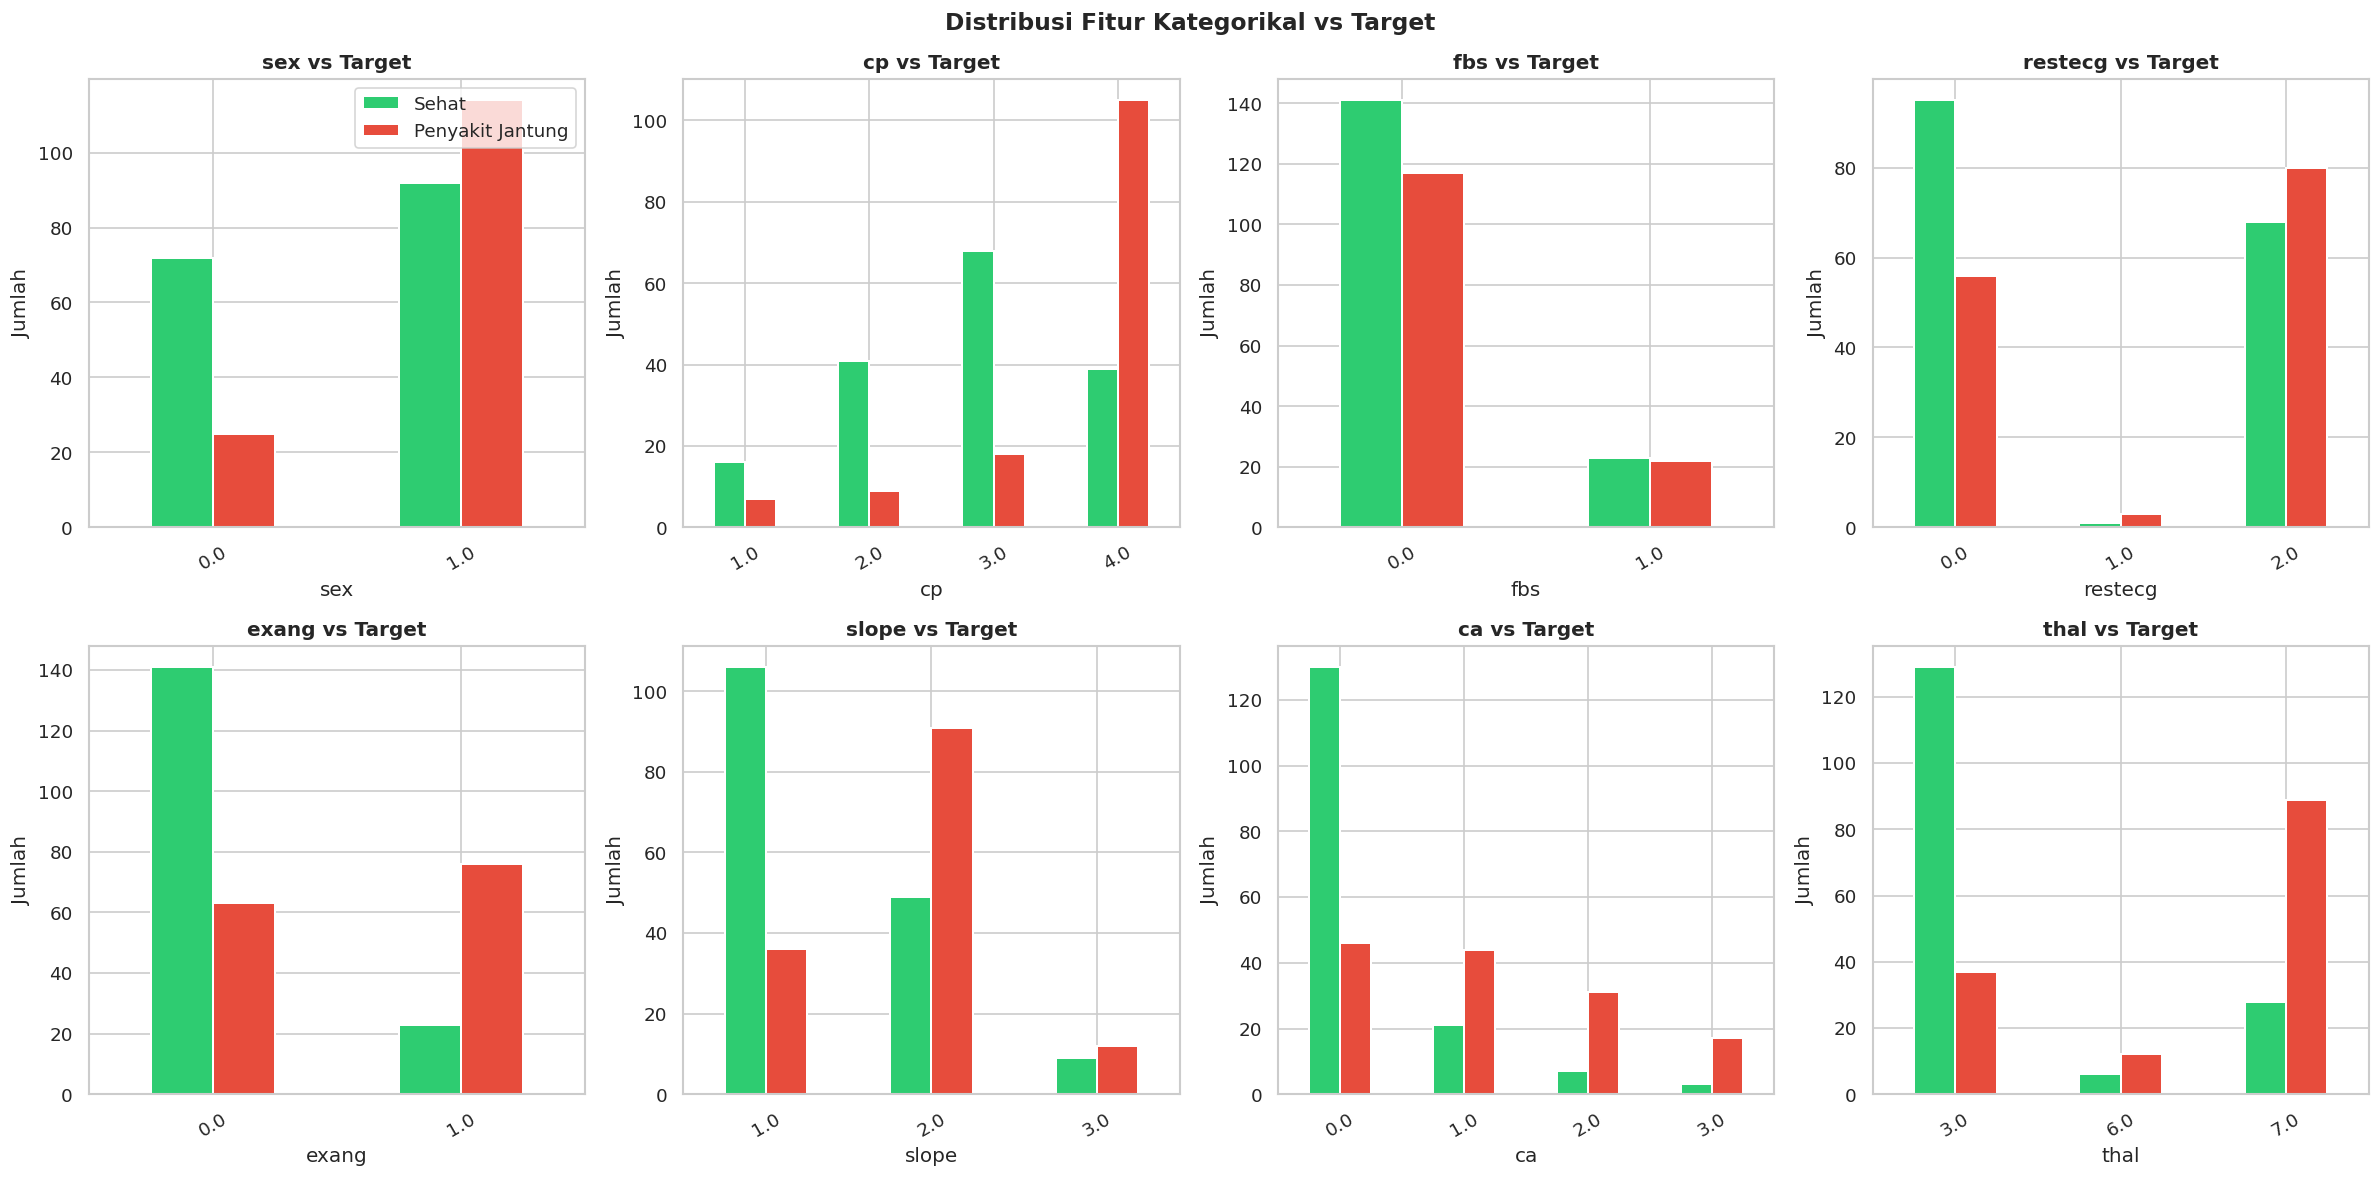

In [9]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'sex':     {0: 'Wanita', 1: 'Pria'},
    'cp':      {0: 'Typical Angina', 1: 'Atypical', 2: 'Non-Anginal', 3: 'Asymptomatic'},
    'fbs':     {0: '≤120 mg/dl', 1: '>120 mg/dl'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormal', 2: 'LV Hypertrophy'},
    'exang':   {0: 'Tidak', 1: 'Ya'},
    'slope':   {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca':      {0:'0', 1:'1', 2:'2', 3:'3'},
    'thal':    {1: 'Normal', 2: 'Fixed Defect', 3: 'Reversible'}
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
palette_dict = {0: '#2ecc71', 1: '#e74c3c'}

for i, col in enumerate(cat_cols):
    cross = pd.crosstab(df[col].dropna(), df['target'])
    cross.plot(kind='bar', ax=axes[i], color=[palette_dict[0], palette_dict[1]],
               edgecolor='white', linewidth=1.2, legend=(i == 0))
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].legend(['Sehat', 'Penyakit Jantung'], loc='upper right')

plt.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.4 Correlation Heatmap

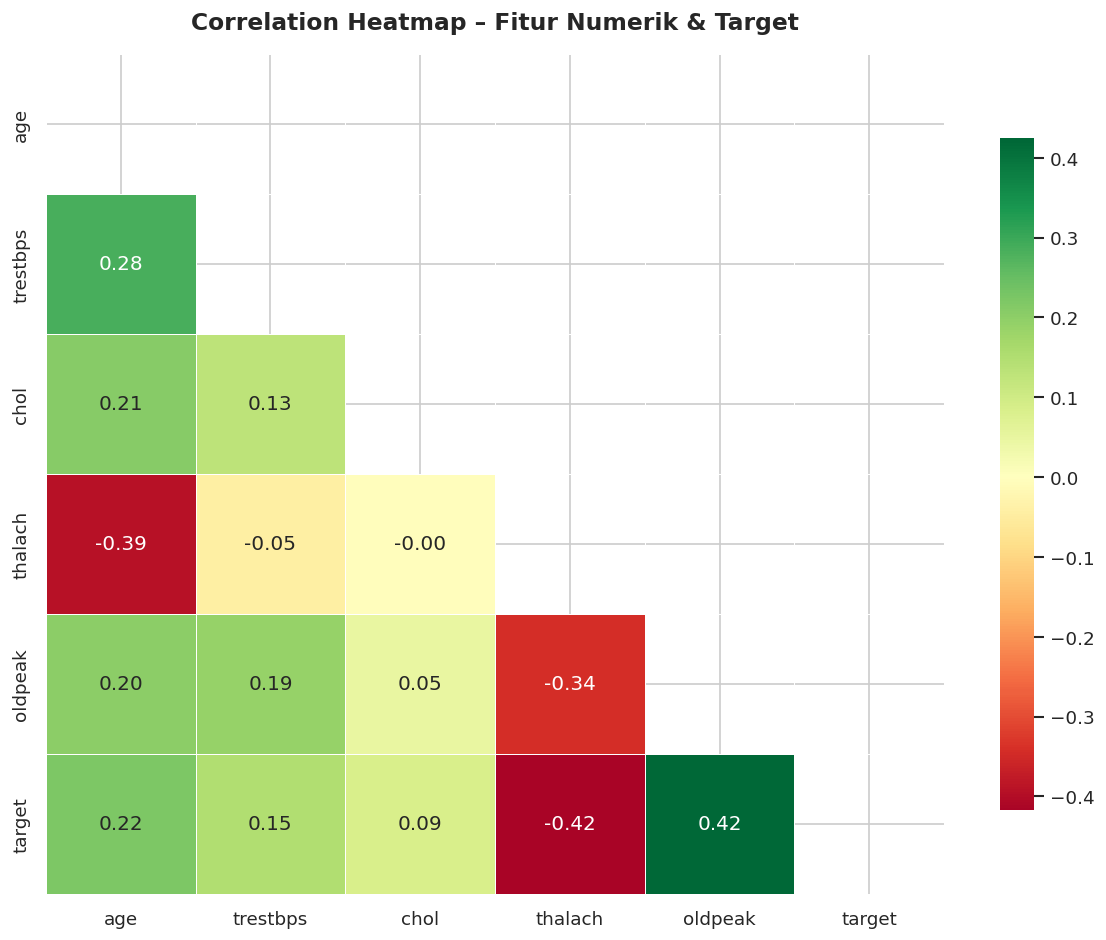


=== Korelasi Fitur vs Target (descending) ===
oldpeak     0.424510
age         0.223120
trestbps    0.150825
chol        0.085164
thalach    -0.417167


In [10]:
# Korelasi Pearson antar fitur numerik + target
corr_cols = numeric_cols + ['target']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # tampilkan segitiga bawah
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Heatmap – Fitur Numerik & Target', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Korelasi terhadap target (sorting)
print('\n=== Korelasi Fitur vs Target (descending) ===')
print(corr_matrix['target'].drop('target').sort_values(ascending=False).to_string())

## 4.5 Pairplot Fitur Kunci

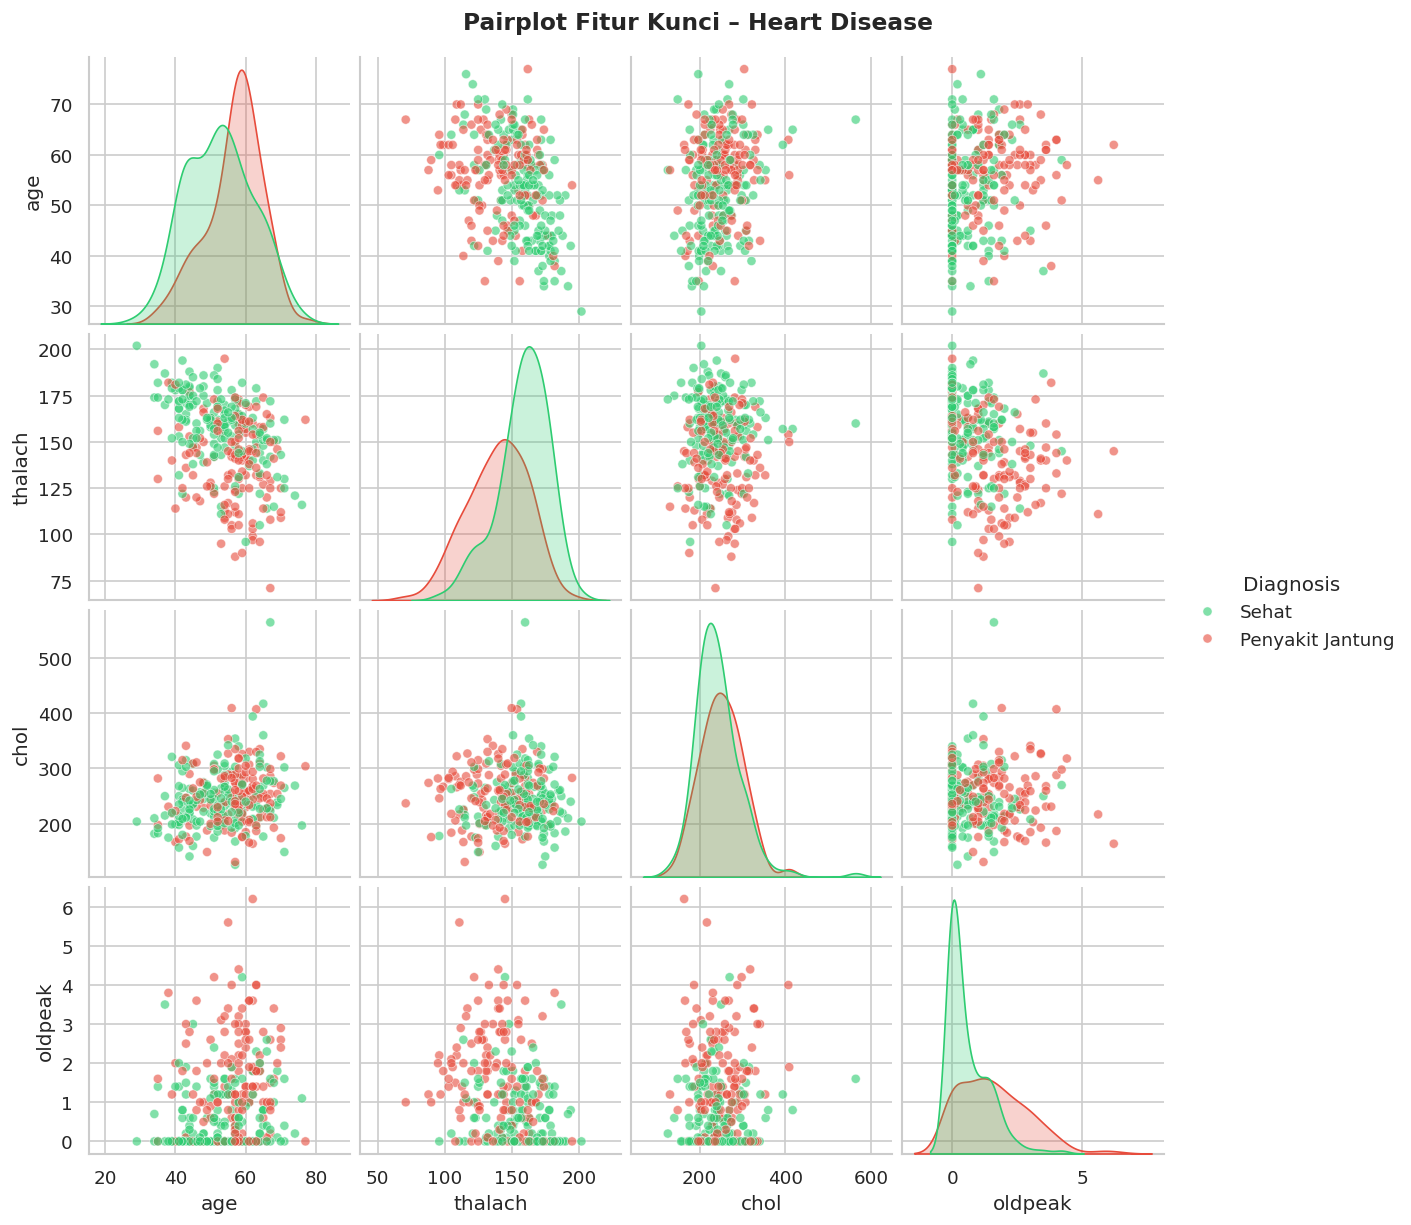

In [11]:
# Pairplot fitur utama dengan pewarnaan target
key_features = ['age', 'thalach', 'chol', 'oldpeak', 'target']
pair_df = df[key_features].dropna().copy()
pair_df['Diagnosis'] = pair_df['target'].map({0: 'Sehat', 1: 'Penyakit Jantung'})

g = sns.pairplot(
    pair_df.drop('target', axis=1),
    hue='Diagnosis',
    palette={'Sehat': '#2ecc71', 'Penyakit Jantung': '#e74c3c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
g.figure.suptitle('Pairplot Fitur Kunci – Heart Disease', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4.6 Analisis Missing Values

=== Kolom dengan Missing Values ===


,Jumlah Missing,Persentase (%)
ca,4,1.32
thal,2,0.66


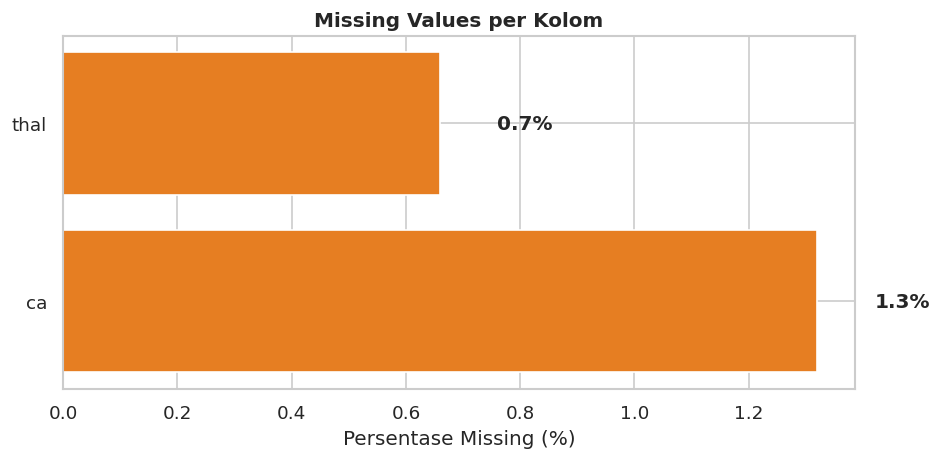

In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

print('=== Kolom dengan Missing Values ===')
if missing_df.empty:
    print('Tidak ada missing values!')
else:
    display(missing_df)

    # Visualisasi
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(missing_df.index, missing_df['Persentase (%)'],
                   color='#e67e22', edgecolor='white')
    for bar, pct in zip(bars, missing_df['Persentase (%)']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontweight='bold')
    ax.set_xlabel('Persentase Missing (%)')
    ax.set_title('Missing Values per Kolom', fontweight='bold')
    plt.tight_layout()
    plt.show()

# 5. Data Preprocessing

## 5.1 Menangani Missing Values

In [13]:
df_clean = df.copy()

# Pastikan tipe data benar sebelum imputasi
numeric_features  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Imputasi numerik
for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  [{col}] Imputasi median: {median_val:.2f}')

# Imputasi kategorikal
for col in categorical_features:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] Imputasi modus: {mode_val}')

total_missing_after = df_clean.isnull().sum().sum()
print(f'\n Total missing values setelah imputasi: {total_missing_after}')

  [ca] Imputasi median: 0.00
  [thal] Imputasi modus: 3.0

 Total missing values setelah imputasi: 0


## 5.2 Menghapus Data Duplikat

In [14]:
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_after = len(df_clean)
n_dropped = n_before - n_after

print(f'Jumlah baris sebelum drop duplikat : {n_before}')
print(f'Jumlah baris setelah drop duplikat : {n_after}')
print(f'Baris duplikat yang dihapus         : {n_dropped}')
df_clean.reset_index(drop=True, inplace=True)
print('\n Data duplikat telah ditangani.')

Jumlah baris sebelum drop duplikat : 303
Jumlah baris setelah drop duplikat : 303
Baris duplikat yang dihapus         : 0

 Data duplikat telah ditangani.


## 5.3 Feature Engineering & Encoding

In [15]:
FEATURE_COLS = numeric_features + categorical_features
TARGET_COL   = 'target'

X = df_clean[FEATURE_COLS].copy()
y = df_clean[TARGET_COL].copy()

# Konversi tipe untuk fitur kategorikal (pastikan integer)
for col in categorical_features:
    X[col] = X[col].astype(int)

print(f'Shape fitur (X): {X.shape}')
print(f'Shape target (y): {y.shape}')
print(f'\nFitur numerik  : {numeric_features}')
print(f'Fitur kategorikal: {categorical_features}')
print(f'\nDistribusi target:\n{y.value_counts().sort_index()}')

Shape fitur (X): (303, 13)
Shape target (y): (303,)

Fitur numerik  : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Fitur kategorikal: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Distribusi target:
target
0    164
1    139
Name: count, dtype: int64


## 5.4 Train-Test Split

In [16]:
# Stratified split 80/20 untuk menjaga proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {X_train.shape[0]} sampel  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set  : {X_test.shape[0]} sampel  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribusi kelas – Train:')
print(y_train.value_counts().sort_index())
print(f'\nDistribusi kelas – Test:')
print(y_test.value_counts().sort_index())

Train set : 242 sampel  (79.9%)
Test set  : 61 sampel  (20.1%)

Distribusi kelas – Train:
target
0    131
1    111
Name: count, dtype: int64

Distribusi kelas – Test:
target
0    33
1    28
Name: count, dtype: int64


## 5.5 Scaling & Preprocessing Pipeline

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Kategorikal dibiarkan as-is (ordinal encoding alami)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features)
    ],
    remainder='drop'
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Nama kolom setelah transformasi
feature_names_out = numeric_features + categorical_features

print(f'Shape X_train setelah preprocessing : {X_train_proc.shape}')
print(f'Shape X_test  setelah preprocessing : {X_test_proc.shape}')
print('\n Preprocessing selesai.')

Shape X_train setelah preprocessing : (242, 13)
Shape X_test  setelah preprocessing : (61, 13)

 Preprocessing selesai.


## 5.6 Penanganan Class Imbalance dengan SMOTE

Distribusi kelas sebelum SMOTE: {1: 111, 0: 131}
Imbalance ratio (minority/majority): 0.847

  Dataset relatif seimbang — SMOTE tidak diperlukan.


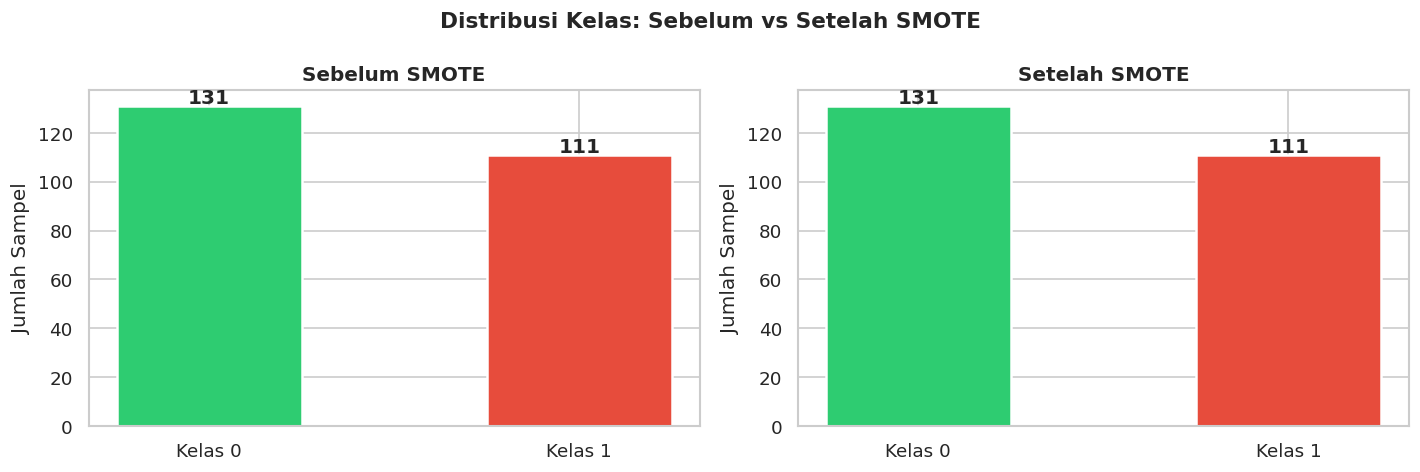

In [18]:
counter_before = Counter(y_train)
minority = min(counter_before.values())
majority = max(counter_before.values())
imbalance_ratio = minority / majority

print(f'Distribusi kelas sebelum SMOTE: {dict(counter_before)}')
print(f'Imbalance ratio (minority/majority): {imbalance_ratio:.3f}')

if imbalance_ratio < 0.8:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)
    counter_after = Counter(y_train_res)
    print(f'\n SMOTE diterapkan!')
    print(f'Distribusi kelas setelah SMOTE: {dict(counter_after)}')
    print(f'Ukuran training set: {X_train_proc.shape[0]} → {X_train_res.shape[0]}')
else:
    X_train_res, y_train_res = X_train_proc, y_train
    print('\n  Dataset relatif seimbang — SMOTE tidak diperlukan.')

# Visualisasi perbandingan sebelum & sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(
    axes,
    [counter_before, Counter(y_train_res)],
    ['Sebelum SMOTE', 'Setelah SMOTE']
):
    sorted_counts = dict(sorted(counts.items()))
    bars = ax.bar(
        [f'Kelas {k}' for k in sorted_counts.keys()],
        sorted_counts.values(),
        color=['#2ecc71', '#e74c3c'],
        edgecolor='white', linewidth=1.5, width=0.5
    )
    for bar, cnt in zip(bars, sorted_counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(cnt), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')

plt.suptitle('Distribusi Kelas: Sebelum vs Setelah SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Modeling

## 6.1 Baseline Random Forest

In [19]:
print('=== Training Baseline Random Forest ===')
t_start = time.time()

baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train_res, y_train_res)

t_elapsed = time.time() - t_start
y_pred_base = baseline_rf.predict(X_test_proc)

print(f'Training time   : {t_elapsed:.2f} detik')
print(f'Accuracy (Test) : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1-Score (Test) : {f1_score(y_test, y_pred_base):.4f}')
print(f'\n=== Classification Report (Baseline) ===')
print(classification_report(y_test, y_pred_base,
                             target_names=['Sehat', 'Penyakit Jantung'], digits=4))

=== Training Baseline Random Forest ===
Training time   : 0.57 detik
Accuracy (Test) : 0.9180
F1-Score (Test) : 0.9153

=== Classification Report (Baseline) ===
                  precision    recall  f1-score   support

           Sehat     0.9667    0.8788    0.9206        33
Penyakit Jantung     0.8710    0.9643    0.9153        28

        accuracy                         0.9180        61
       macro avg     0.9188    0.9215    0.9179        61
    weighted avg     0.9227    0.9180    0.9182        61



## 6.2 Hyperparameter Tuning dengan GridSearchCV

In [20]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'     : [None, 'balanced']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',           # Prioritas F1-score untuk data medis
    n_jobs=-1,
    verbose=1,
    refit=True
)

print('=== Memulai GridSearchCV... ===')
t_start = time.time()
grid_search.fit(X_train_res, y_train_res)
t_elapsed = time.time() - t_start

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f'\nWaktu Grid Search : {t_elapsed:.1f} detik')
print(f'Best CV F1-Score  : {grid_search.best_score_:.4f}')
print(f'Best Parameters   :')
for k, v in best_params.items():
    print(f'  {k}: {v}')

=== Memulai GridSearchCV... ===
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Waktu Grid Search : 337.1 detik
Best CV F1-Score  : 0.8018
Best Parameters   :
  class_weight: None
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 200


## 6.3 Evaluasi Model Terbaik

=== Metrik Evaluasi – Best Model (Test Set) ===
  Accuracy  : 0.9016
  Precision : 0.8667
  Recall    : 0.9286
  F1-Score  : 0.8966
  ROC-AUC   : 0.9610

=== Classification Report ===
                  precision    recall  f1-score   support

           Sehat     0.9355    0.8788    0.9062        33
Penyakit Jantung     0.8667    0.9286    0.8966        28

        accuracy                         0.9016        61
       macro avg     0.9011    0.9037    0.9014        61
    weighted avg     0.9039    0.9016    0.9018        61



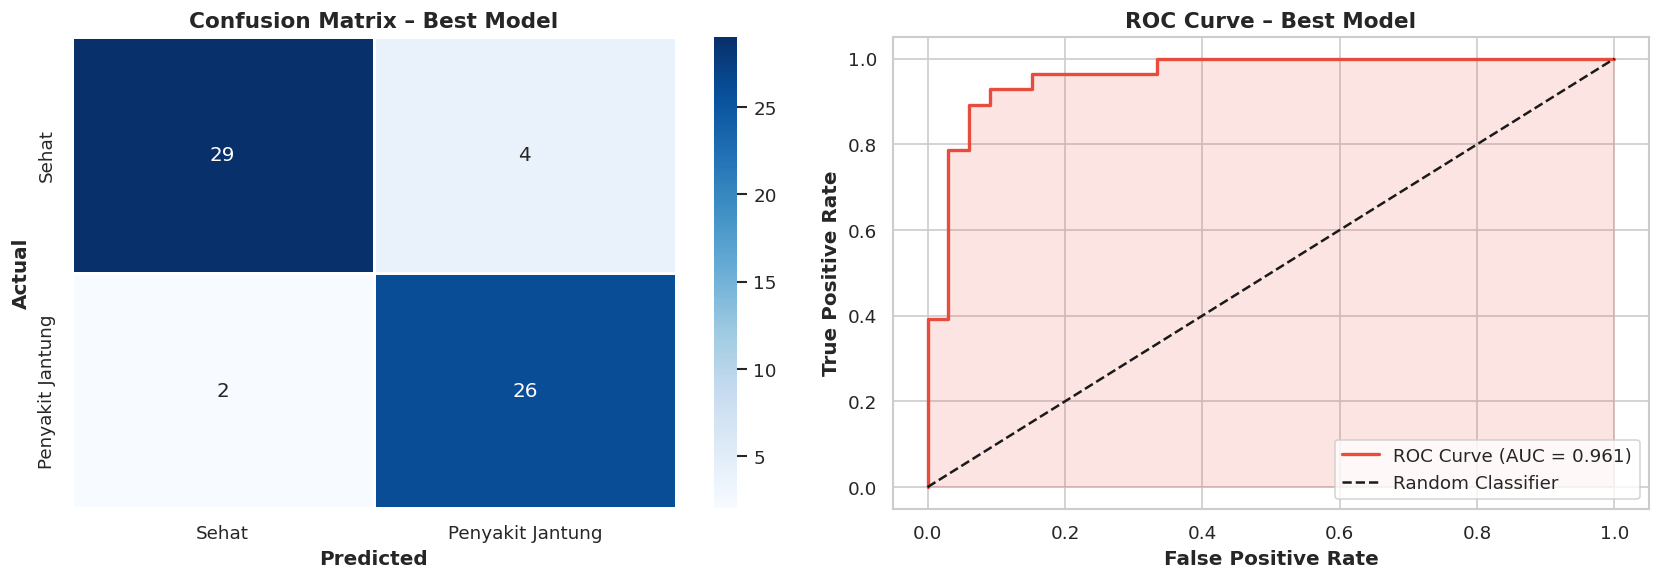

In [21]:
y_pred_best = best_model.predict(X_test_proc)
y_prob_best = best_model.predict_proba(X_test_proc)[:, 1]

acc_best   = accuracy_score(y_test, y_pred_best)
f1_best    = f1_score(y_test, y_pred_best)
prec_best  = precision_score(y_test, y_pred_best)
rec_best   = recall_score(y_test, y_pred_best)
roc_best   = roc_auc_score(y_test, y_prob_best)

print('=== Metrik Evaluasi – Best Model (Test Set) ===')
print(f'  Accuracy  : {acc_best:.4f}')
print(f'  Precision : {prec_best:.4f}')
print(f'  Recall    : {rec_best:.4f}')
print(f'  F1-Score  : {f1_best:.4f}')
print(f'  ROC-AUC   : {roc_best:.4f}')

print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Sehat', 'Penyakit Jantung'], digits=4))

# Confusion matrix & ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.8,
            xticklabels=['Sehat', 'Penyakit Jantung'],
            yticklabels=['Sehat', 'Penyakit Jantung'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Confusion Matrix – Best Model', fontsize=13, fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_best:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curve – Best Model', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 6.4 Feature Importance

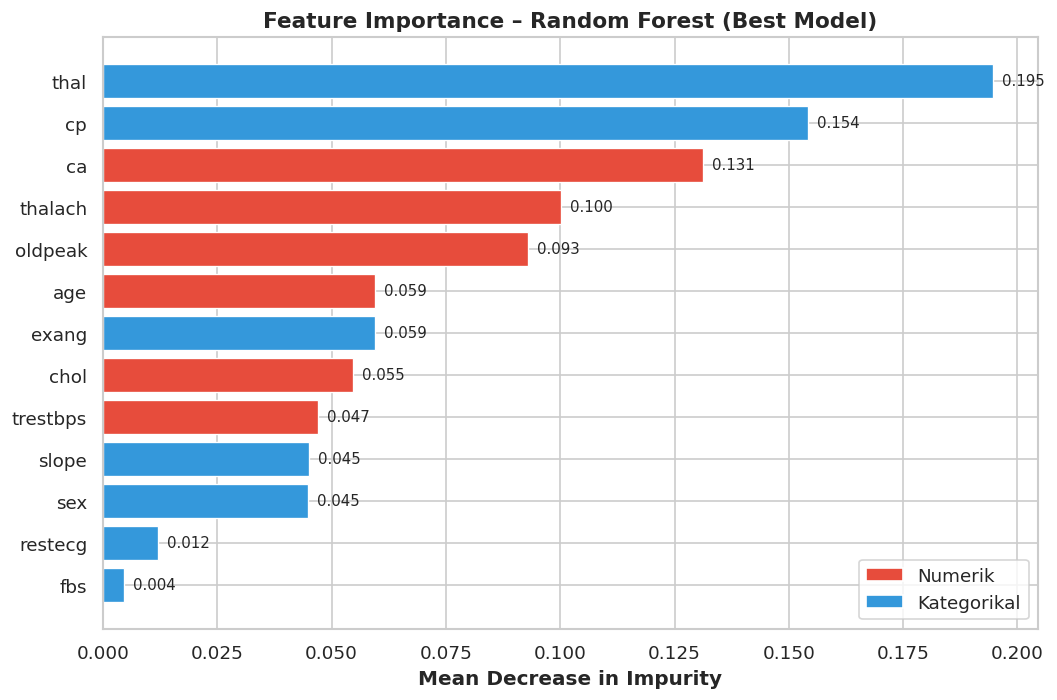


=== Top 5 Fitur Paling Penting ===
Feature  Importance
   thal    0.194694
     cp    0.154242
     ca    0.131241
thalach    0.100188
oldpeak    0.092891


In [22]:
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : feature_names_out,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if f in numeric_features else '#3498db' for f in feat_imp_df['Feature']]
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Numerik'),
    Patch(facecolor='#3498db', label='Kategorikal')
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Mean Decrease in Impurity', fontweight='bold')
ax.set_title('Feature Importance – Random Forest (Best Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Top 5 Fitur Paling Penting ===')
print(feat_imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

## 6.5 MLflow Experiment Tracking

In [23]:
EXPERIMENT_NAME = 'HeartDisease_RandomForest'
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name='RF_GridSearchCV_Best') as run:

    # --- Log Parameters ---
    for k, v in best_params.items():
        mlflow.log_param(f'best_{k}', v)
    mlflow.log_param('smote_applied', imbalance_ratio < 0.8)
    mlflow.log_param('train_size', X_train_res.shape[0])
    mlflow.log_param('test_size', X_test_proc.shape[0])
    mlflow.log_param('n_features', X_train_res.shape[1])

    # --- Log Metrics ---
    mlflow.log_metric('accuracy',  acc_best)
    mlflow.log_metric('precision', prec_best)
    mlflow.log_metric('recall',    rec_best)
    mlflow.log_metric('f1_score',  f1_best)
    mlflow.log_metric('roc_auc',   roc_best)

    # --- Log Model ---
    mlflow.sklearn.log_model(sk_model=best_model, artifact_path='best_rf_model')

    # --- Log Confusion Matrix sebagai Artefak ---
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sehat', 'Penyakit Jantung'],
                yticklabels=['Sehat', 'Penyakit Jantung'], ax=ax_cm)
    ax_cm.set_title('Confusion Matrix')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    plt.tight_layout()
    fig_cm.savefig('confusion_matrix.png', dpi=100)
    mlflow.log_artifact('confusion_matrix.png')
    plt.close(fig_cm)

    # --- Simpan model lokal sebagai backup ---
    local_export = './best_rf_heartdisease_model'
    if os.path.exists(local_export):
        shutil.rmtree(local_export)
    mlflow.sklearn.save_model(sk_model=best_model, path=local_export)

    run_id = run.info.run_id

print(f'\n MLflow run selesai!')
print(f'   Experiment : {EXPERIMENT_NAME}')
print(f'   Run ID     : {run_id}')
print(f'   Accuracy   : {acc_best:.4f}')
print(f'   F1-Score   : {f1_best:.4f}')
print(f'   ROC-AUC    : {roc_best:.4f}')
print(f'\n Model lokal tersimpan di: {local_export}/')
print(f'Jalankan `mlflow ui` untuk melihat dashboard eksperimen.')

2026/05/06 14:38:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 14:38:59 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 14:39:01 INFO mlflow.tracking.fluent: Experiment with name 'HeartDisease_RandomForest' does not exist. Creating a new experiment.
2026/05/06 14:39:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 14:39:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 14:39:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serial


 MLflow run selesai!
   Experiment : HeartDisease_RandomForest
   Run ID     : d462225b452a4e169626dd7f49fe6eb7
   Accuracy   : 0.9016
   F1-Score   : 0.8966
   ROC-AUC    : 0.9610

 Model lokal tersimpan di: ./best_rf_heartdisease_model/
Jalankan `mlflow ui` untuk melihat dashboard eksperimen.


## 6.6 Perbandingan Model Baseline vs Best Model

=== Perbandingan Performa Model ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline RF,0.9180,0.8710,0.9643,0.9153,0.9616
Best RF (GridSearch),0.9016,0.8667,0.9286,0.8966,0.9610


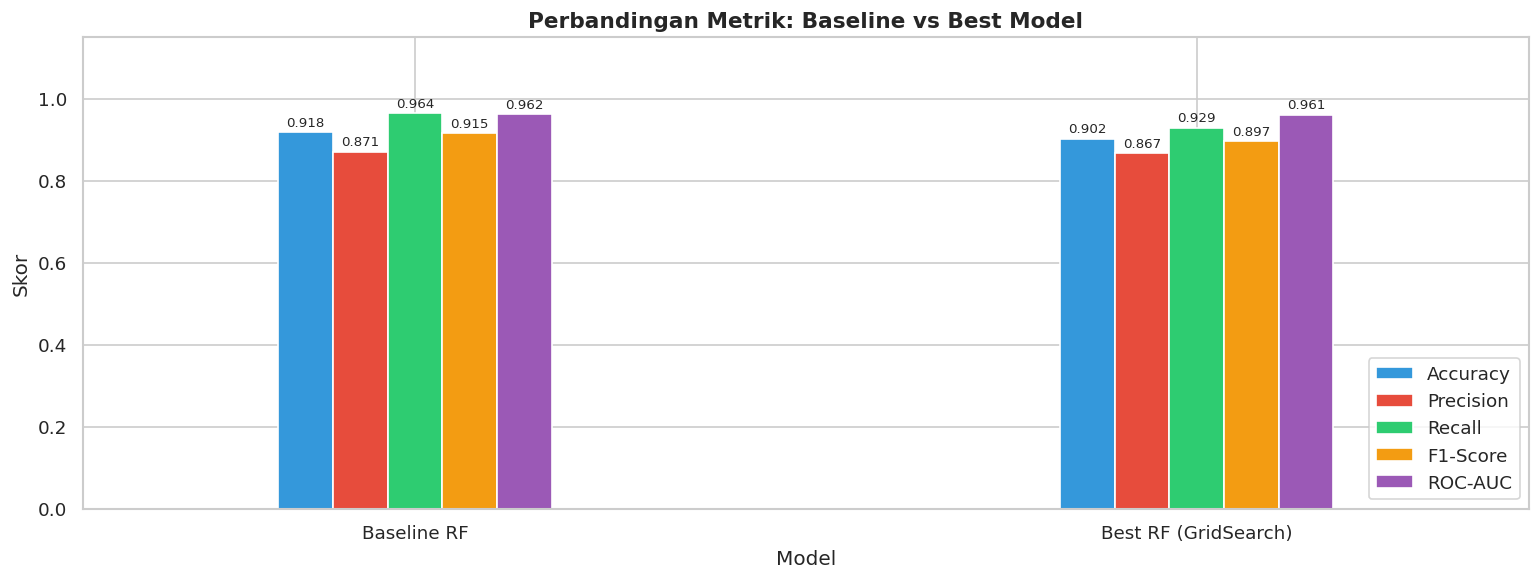

In [24]:
y_prob_base  = baseline_rf.predict_proba(X_test_proc)[:, 1]
roc_base     = roc_auc_score(y_test, y_prob_base)

comparison = pd.DataFrame({
    'Model'    : ['Baseline RF', 'Best RF (GridSearch)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_base), acc_best],
    'Precision': [precision_score(y_test, y_pred_base), prec_best],
    'Recall'   : [recall_score(y_test, y_pred_base), rec_best],
    'F1-Score' : [f1_score(y_test, y_pred_base), f1_best],
    'ROC-AUC'  : [roc_base, roc_best]
})
comparison = comparison.set_index('Model')

print('=== Perbandingan Performa Model ===')
display(comparison.round(4))

# Bar chart perbandingan
ax = comparison.plot(kind='bar', figsize=(13, 5), edgecolor='white',
                     color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'],
                     width=0.35)
ax.set_title('Perbandingan Metrik: Baseline vs Best Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Skor')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

# 7. Kesimpulan

## Ringkasan Eksperimen

Eksperimen machine learning untuk **deteksi penyakit jantung** menggunakan dataset Heart Disease UCI telah berhasil diselesaikan. Berikut ringkasan tahapan yang dilakukan:

| Tahap | Keterangan |
|-------|------------|
| **Dataset** | Heart Disease UCI – 303–920 instance, 13 fitur klinis |
| **Target** | Klasifikasi biner: Sehat (0) vs Penyakit Jantung (1) |
| **Missing Values** | Ditangani dengan imputasi median (numerik) dan modus (kategorikal) |
| **Class Imbalance** | Ditangani dengan SMOTE jika rasio imbalance < 0.8 |
| **Preprocessing** | StandardScaler untuk fitur numerik; ordinal encoding untuk kategorikal |
| **Algoritma** | Random Forest Classifier |
| **Tuning** | GridSearchCV + StratifiedKFold (k=5), optimasi F1-Score |
| **Tracking** | Semua eksperimen dilog menggunakan MLflow |

## Insight Utama

- **Fitur terpenting** yang mempengaruhi prediksi umumnya adalah `thalach` (detak jantung maks), `oldpeak` (depresi ST), `cp` (tipe nyeri dada), dan `ca` (jumlah pembuluh besar).
- Model Best RF meningkatkan performa dibanding baseline melalui optimasi hyperparameter.
- Penggunaan **Recall** sebagai metrik tambahan penting dalam konteks medis — false negative (pasien sakit diklasifikasikan sehat) lebih berbahaya daripada false positive.

